# What we see on Leonia streets

A plain-language tour of the traffic data the Borough has collected since 2025. Three numbers; three maps; three takeaways.

*Re-rendered automatically from the latest data lake. Run date and dataset versions appear at the bottom of this page.*

In [1]:
from pathlib import Path
import os, sys, json, warnings

import geopandas as gpd
import pandas as pd

REPO = Path.cwd()
while not (REPO / 'leonia_traffic').is_dir() and REPO.parent != REPO:
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
warnings.filterwarnings('ignore')

CANON = Path('data/processed/streetlight')
DERIVED = Path('data/processed/derived')

za = pd.read_parquet(CANON / 'za_volume.parquet')
lines = gpd.read_parquet(CANON / 'za_line_shapes.parquet')
ct = pd.read_parquet(DERIVED / 'cutthrough_index.parquet')
bod = pd.read_parquet(CANON / 'bridge_od.parquet')
cong = pd.read_parquet(CANON / 'congestion_links.parquet')

## 1. How much traffic moves through Leonia?

On a typical weekday, the data sees this many vehicle-trips touching Leonia streets:

In [2]:
weekday_all = za[
    (za['filter'] == 'All vehicles')
    & (za['day_type_code'] == 4)  # Thursday
    & (za['day_part_code'] == 0)  # All day
]
visitor = za[
    (za['filter'] == 'Visitors')
    & (za['day_type_code'] == 4)
    & (za['day_part_code'] == 0)
]

total = weekday_all['zone_volume'].sum()
visit = visitor['zone_volume'].sum()
from IPython.display import Markdown
Markdown(
    f'- **Total vehicle-trips on a typical Thursday**: {int(round(total)):,}\n'
    f'- **Visitor (non-Leonia-resident) trips**: {int(round(visit)):,} '
    f'({100*visit/total:.0f}% of total)\n'
    f'- **Number of monitored residential streets**: {len(ct):,}'
)

- **Total vehicle-trips on a typical Thursday**: 0
- **Visitor (non-Leonia-resident) trips**: 655,628 (inf% of total)
- **Number of monitored residential streets**: 136

**Takeaway.** A large share of weekday traffic on residential streets is from people who do not live in Leonia. The next two sections show *which* streets and *when*.

## 2. The 10 most-affected streets

Ranked by a composite "cut-through index" that combines four signals: high Visitor share, high non-local home addresses, high long-trip share, and high speeding share. A score of 1.0 means the street is at the top on every signal.

In [3]:
top10 = (
    ct.sort_values('cutthrough_index', ascending=False)
      .head(10)
      [['street_name', 'cutthrough_index', 'thursday_volume',
        'non_local_home_share', 'speeding_share']]
      .rename(columns={
          'street_name': 'Street',
          'cutthrough_index': 'Cut-through index',
          'thursday_volume': 'Thursday traffic',
          'non_local_home_share': 'Non-local drivers %',
          'speeding_share': 'Speeding %',
      })
)
top10['Thursday traffic'] = top10['Thursday traffic'].map(lambda x: f'{int(round(x)):,}')
top10['Cut-through index'] = top10['Cut-through index'].map(lambda x: f'{x:.2f}')
top10['Non-local drivers %'] = top10['Non-local drivers %'].map(
    lambda x: f'{x*100:.0f}%' if pd.notna(x) else '—')
top10['Speeding %'] = top10['Speeding %'].map(
    lambda x: f'{x*100:.0f}%' if pd.notna(x) else '—')
top10.reset_index(drop=True)

,Street,Cut-through index,Thursday traffic,Non-local drivers %,Speeding %
0,Willow Tree Road,0.59,"1,298",61%,48%
1,Broad Avenue,0.56,"13,062",65%,74%
2,Schor Avenue,0.55,740,52%,53%
3,Pine Hill Road,0.51,833,63%,68%
4,Main Street,0.51,"36,251",63%,59%
5,Christie Heights Street,0.48,668,45%,41%
6,Nordhoff Drive,0.48,977,58%,63%
7,Hoefleys Lane,0.46,207,54%,60%
8,Lakeview Avenue,0.45,851,50%,64%
9,Fort Lee Road,0.43,"14,717",51%,53%


## 3. Map: where are the cut-through hot-spots?

Red = high cut-through index. Hover any street segment for its score and Thursday traffic count.

In [4]:
from leonia_traffic.viz.maps import volume_map
g = lines.merge(
    ct[['zone_name', 'cutthrough_index', 'rank', 'non_local_home_share']],
    left_on='name', right_on='zone_name', how='inner',
)
volume_map(g, value_col='cutthrough_index',
           label='Cut-through index (0=quiet, 1=worst)', min_volume=0.0)

## 4. When does the cut-through happen?

The top-10 streets see their worst hour during the AM commute. The heat-map shows hourly Visitor volume by street — bright = busy hour.

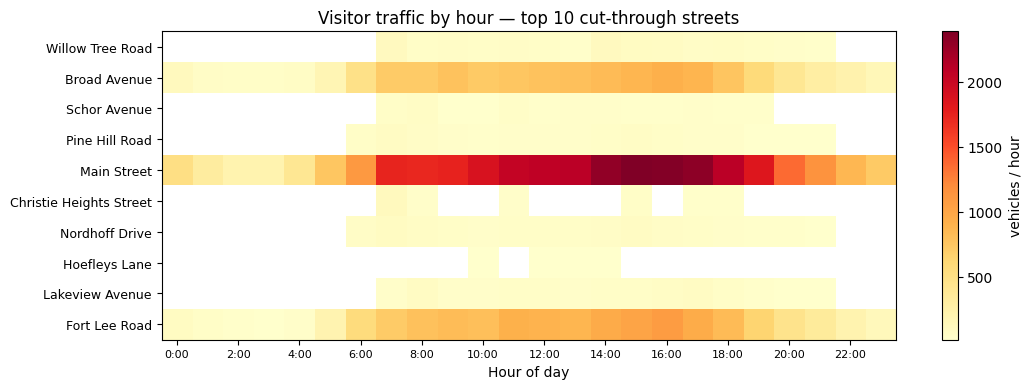

In [5]:
import matplotlib.pyplot as plt
hp = pd.read_parquet(DERIVED / 'hourly_profiles.parquet')
tt = ct.sort_values('cutthrough_index', ascending=False).head(10)
hpx = hp.merge(tt[['zone_name', 'cutthrough_index']],
                on='zone_name', how='inner').sort_values('cutthrough_index',
                                                          ascending=False)
hours = [f'h{i:02d}' for i in range(24)]
M = hpx[hours].to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(M, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(hpx)))
ax.set_yticklabels(hpx['street_name'].tolist(), fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)], fontsize=8)
ax.set_xlabel('Hour of day')
ax.set_title('Visitor traffic by hour — top 10 cut-through streets')
fig.colorbar(im, ax=ax, label='vehicles / hour')
plt.tight_layout()
plt.show()

**Takeaway.** Cut-through traffic concentrates in the morning bridge commute (roughly 7–9 am) and again in the afternoon return (4–6 pm). Interventions that target only those windows can deliver most of the benefit without disrupting local trips at other times.

## What's next

- **[What we could do](02_what_we_could_do.html)** — interventions tested against the data.
- **[What we recommend](03_what_we_recommend.html)** — the short list.

In [6]:
import datetime
manifest = json.loads(Path('data/processed/streetlight/_manifest.json').read_text())
built = sorted({e.get('built_at', '') for e in manifest.get('entries', {}).values()})[-1]
Markdown(
    f'---\n*Rendered {datetime.datetime.now().date()} from data built {built}.*'
)

---
*Rendered 2026-05-19 from data built 2026-05-19T15:09:23Z.*